In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"seattle-weather.csv")
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
data.shape

(1461, 6)

In [4]:
data.isna().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 88.0 KB


In [19]:
# set 'date' dtype to datatime
data['date']= pd.to_datetime(data['date'])

In [20]:
data.weather.value_counts()

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

In [21]:
data.describe()

,date,precipitation,temp_max,temp_min,wind
count,1461,1461.000000,1461.000000,1461.000000,1461.000000
mean,2013-12-31 00:00:00,3.029432,16.439083,8.234771,3.241136
min,2012-01-01 00:00:00,0.000000,-1.600000,-7.100000,0.400000
25%,2012-12-31 00:00:00,0.000000,10.600000,4.400000,2.200000
50%,2013-12-31 00:00:00,0.000000,15.600000,8.300000,3.000000
75%,2014-12-31 00:00:00,2.800000,22.200000,12.200000,4.000000
max,2015-12-31 00:00:00,55.900000,35.600000,18.300000,9.500000
std,NaN,6.680194,7.349758,5.023004,1.437825


In [22]:
data.duplicated().sum()

np.int64(0)

In [23]:
df = data.sort_values(by='date').copy()

In [24]:
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [25]:
# set index
df.set_index('date', inplace=True)

In [26]:
df.head()

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


In [27]:
df.resample('W')['temp_max'].mean()

date
2012-01-01    12.800000
2012-01-08     9.285714
2012-01-15     5.457143
2012-01-22     3.728571
2012-01-29     8.414286
                ...    
2015-12-06    10.742857
2015-12-13    10.957143
2015-12-20     7.471429
2015-12-27     5.400000
2016-01-03     5.850000
Freq: W-SUN, Name: temp_max, Length: 210, dtype: float64

In [29]:
df.resample('W')['precipitation'].max()

date
2012-01-01     0.0
2012-01-08    20.3
2012-01-15     5.3
2012-01-22    19.8
2012-01-29    27.7
              ... 
2015-12-06    15.7
2015-12-13    54.1
2015-12-20    21.8
2015-12-27    27.4
2016-01-03     1.5
Freq: W-SUN, Name: precipitation, Length: 210, dtype: float64

In [30]:
df.resample('YE')['precipitation'].mean()

date
2012-12-31    3.349727
2013-12-31    2.268493
2014-12-31    3.377534
2015-12-31    3.121096
Freq: YE-DEC, Name: precipitation, dtype: float64

In [31]:
df.resample('ME')[['precipitation','temp_max','temp_min','wind']].agg(['min','max','mean'])

precipitation                 temp_max                  temp_min  \
                     min   max      mean      min   max       mean      min   
date                                                                          
2012-01-31           0.0  27.7  5.590323     -1.1  12.8   7.054839     -3.3   
2012-02-29           0.0  17.3  3.182759      5.0  16.1   9.275862     -2.2   
2012-03-31           0.0  27.4  5.903226      5.0  15.6   9.554839     -1.7   
2012-04-30           0.0  10.9  2.270000      8.9  23.3  14.873333      1.7   
2012-05-31           0.0  18.5  1.683871     11.1  26.7  17.661290      3.9   
2012-06-30           0.0  16.5  2.503333     12.8  24.4  18.693333      6.1   
2012-07-31           0.0  15.2  0.848387     18.3  28.3  22.906452      9.4   
2012-08-31           0.0   0.0  0.000000     21.1  34.4  25.858065     10.0   
2012-09-30           0.0   0.3  0.030000     16.1  32.2  22.880000      7.8   
2012-10-31           0.0  34.5  5.493548      7.8  23.9  15.829032      3.3   
2012-11-30           0.0  54.1  7.016667      7.8  17.8  11.326667     -0.6   
2012-12-31           0.0  22.6  5.612903      3.3  13.3   7.235484     -1.7   
2013-01-31           0.0  38.4  3.409677      1.1  11.7   6.106452     -4.4   
2013-02-28           0.0   9.4  1.439286      6.1  13.3   9.467857      1.1   
2013-03-31           0.0  11.9  2.248387      7.2  20.6  12.709677      0.0   
2013-04-30           0.0  39.1  4.986667      7.8  21.7  14.243333      3.3   
2013-05-31           0.0  13.7  1.951613     11.1  30.6  19.625806      3.3   
2013-06-30           0.0   9.9  1.103333     17.2  33.9  23.253333     10.0   
2013-07-31           0.0   0.0  0.000000     19.4  31.7  26.093548     11.1   
2013-08-31           0.0  19.3  1.109677     17.2  31.1  26.119355     13.3   
2013-09-30           0.0  43.4  5.226667     13.9  33.9  21.360000      7.2   
2013-10-31           0.0   9.1  1.264516     10.0  22.8  14.229032      3.3   
2013-11-30           0.0  30.0  3.210000      7.8  17.8  12.053333     -0.5   
2013-12-31           0.0  10.7  1.367742      0.0  13.3   7.022581     -7.1   
2014-01-31           0.0  21.6  3.032258      5.6  14.4   9.600000     -0.5   
2014-02-28           0.0  26.4  5.542857     -1.6  14.4   8.200000     -6.0   
2014-03-31           0.0  46.7  7.741935      7.2  18.9  12.906452      1.1   
2014-04-30           0.0  18.5  3.536667     11.1  27.8  15.460000      4.4   
2014-05-31           0.0  33.3  2.580645     13.3  29.4  19.870968      7.2   
2014-06-30           0.0   6.4  0.626667     15.6  26.1  21.590000      8.9   
2014-07-31           0.0  19.3  0.632258     18.9  34.4  26.900000     11.7   
2014-08-31           0.0  21.6  1.483871     17.8  35.6  26.383871     11.1   
2014-09-30           0.0  20.3  1.890000     16.7  32.2  23.163333     10.0   
2014-10-31           0.0  32.0  5.532258     12.8  25.6  17.961290      6.7   
2014-11-30           0.0  34.3  4.103333      2.8  16.7  11.030000     -4.9   
2014-12-31           0.0  20.6  3.929032      3.3  18.9  10.138710     -3.2   
2015-01-31           0.0  26.2  3.000000      5.0  17.2  10.154839     -3.2   
2015-02-28           0.0  26.2  4.792857      9.4  16.7  12.517857      0.6   
2015-03-31           0.0  55.9  3.661290     10.6  20.6  14.377419     -0.5   
2015-04-30           0.0  14.0  1.720000     11.1  25.0  15.503333      2.8   
2015-05-31           0.0   6.1  0.477419     12.2  27.8  20.025806      6.1   
2015-06-30           0.0   4.6  0.196667     16.1  33.3  26.063333      9.4   
2015-07-31           0.0   2.0  0.074194     21.1  35.0  28.093548     12.2   
2015-08-31           0.0  32.5  2.687097     18.3  33.3  26.087097     12.2   
2015-09-30           0.0   5.8  0.703333     15.6  27.2  20.293333      7.2   
2015-10-31           0.0  33.0  3.948387     12.2  23.3  17.538710      7.2   
2015-11-30           0.0  47.2  7.086667      1.7  15.6   9.683333     -3.8   
2015-12-31           0.0  54.1  9.177419      4.4  15.6   8.3

In [42]:
df_year = df.resample('YS')[['precipitation','temp_max','temp_min','wind']].agg(['min','max','mean']).reset_index()
df_year

date precipitation                 temp_max                  temp_min  \
                       min   max      mean      min   max       mean      min   
0 2012-01-01           0.0  54.1  3.349727     -1.1  34.4  15.276776     -3.3   
1 2013-01-01           0.0  43.4  2.268493      0.0  33.9  16.058904     -7.1   
2 2014-01-01           0.0  46.7  3.377534     -1.6  35.6  16.995890     -6.0   
3 2015-01-01           0.0  55.9  3.121096      1.7  35.0  17.427945     -3.8   

                  wind                 
    max      mean  min  max      mean  
0  18.3  7.289617  1.0  9.5  3.400820  
1  18.3  8.153973  0.4  8.8  3.015890  
2  17.8  8.662466  0.6  8.8  3.387671  
3  18.3  8.835616  0.5  8.0  3.159726

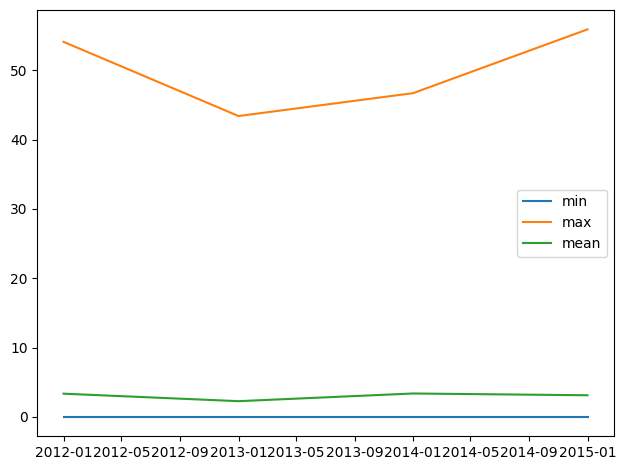

In [61]:
plt.plot(df_year['date'], df_year['precipitation'], label=['min','max','mean'])
plt.tight_layout()
plt.legend()

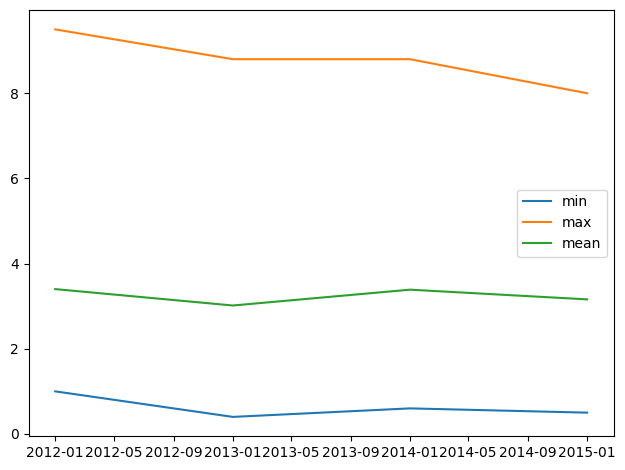

In [62]:
plt.plot(df_year['date'], df_year['wind'], label=['min','max','mean'])
plt.tight_layout()
plt.legend()

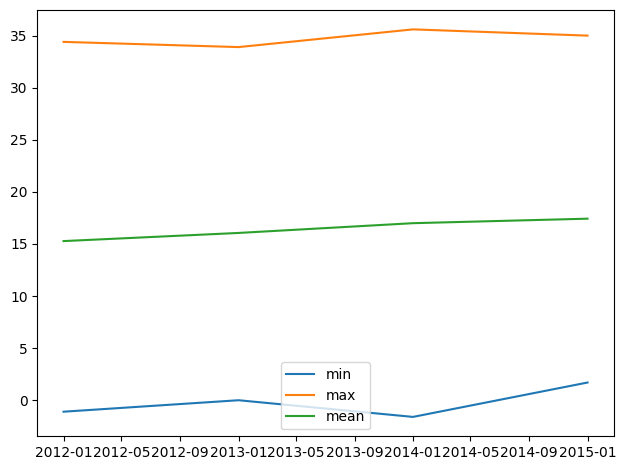

In [63]:
plt.plot(df_year['date'], df_year['temp_max'], label=['min','max','mean'])
plt.tight_layout()
plt.legend()

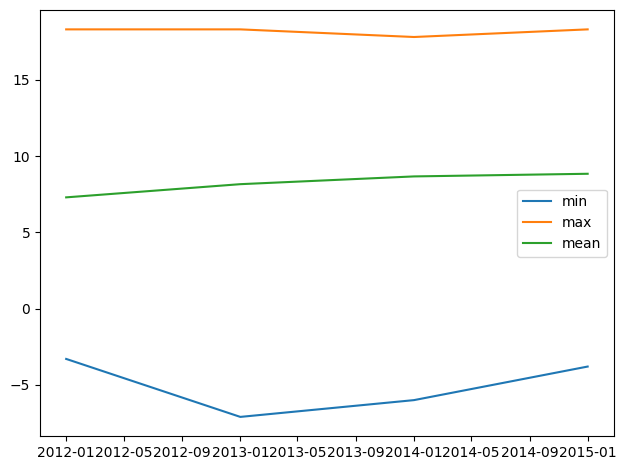

In [64]:
plt.plot(df_year['date'], df_year['temp_min'], label=['min','max','mean'])
plt.tight_layout()
plt.legend()

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [66]:
# X, y parameters
df.head(2)

,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain


In [67]:
X = df[['precipitation','temp_max','temp_min','wind']]
y = df['weather']

In [68]:
X.head(2)

,precipitation,temp_max,temp_min,wind
date,,,,
2012-01-01,0.0,12.8,5.0,4.7
2012-01-02,10.9,10.6,2.8,4.5


In [69]:
y.head(2)

date
2012-01-01    drizzle
2012-01-02       rain
Name: weather, dtype: str

In [70]:
le = LabelEncoder()

In [71]:
y_encoded = le.fit_transform(y)
y_encoded

array([0, 2, 2, ..., 1, 4, 4], shape=(1461,))

In [73]:
df['weather_encoded'] = y_encoded

In [75]:
y = y_encoded
y

array([0, 2, 2, ..., 1, 4, 4], shape=(1461,))

In [76]:
# X,y split into train and test 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [77]:
# create model 
from sklearn.ensemble import RandomForestClassifier

In [78]:
rf = RandomForestClassifier()

In [79]:
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
y_pred = rf.predict(X_test)
y_pred

array([4, 2, 4, 0, 2, 2, 4, 4, 2, 4, 4, 4, 2, 4, 4, 2, 4, 2, 4, 4, 2, 4,
       2, 4, 4, 2, 4, 4, 4, 4, 2, 4, 4, 3, 4, 2, 2, 2, 2, 4, 2, 4, 4, 4,
       4, 2, 2, 4, 2, 4, 4, 2, 4, 2, 4, 2, 2, 4, 2, 4, 2, 4, 2, 4, 4, 4,
       2, 4, 2, 2, 2, 4, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 2, 4, 2, 4, 4, 2,
       4, 2, 2, 4, 4, 2, 2, 4, 4, 2, 4, 2, 4, 4, 2, 3, 2, 4, 4, 2, 4, 2,
       2, 4, 2, 2, 4, 0, 4, 4, 4, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 2, 2, 2, 4, 4, 4, 2, 2, 4, 4, 4, 2, 4, 4, 2, 4, 4, 4,
       2, 2, 1, 4, 2, 2, 4, 4, 2, 4, 1, 2, 2, 4, 4, 4, 2, 2, 4, 4, 2, 2,
       4, 4, 4, 2, 4, 4, 4, 2, 2, 4, 2, 2, 4, 4, 4, 4, 4, 2, 4, 4, 2, 2,
       2, 2, 2, 4, 0, 2, 4, 2, 2, 4, 3, 4, 2, 4, 4, 4, 4, 4, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 2, 4, 2, 4, 2, 4, 2, 4, 4, 2, 4, 4, 4, 4, 4, 2, 2,
       4, 2, 4, 4, 4, 4, 2, 2, 2, 2, 2, 4, 4, 4, 2, 4, 2, 2, 2, 2, 4, 2,
       4, 4, 2, 1, 4, 4, 4, 1, 4, 2, 4, 4, 2, 2, 4, 4, 4, 2, 4, 2, 4, 4,
       2, 4, 4, 2, 4, 2, 4])

In [82]:
acc_score = accuracy_score(y_test,y_pred)
print("Random Forest Accuracy score is : ", acc_score)

Random Forest Accuracy score is :  0.825938566552901


In [85]:
print("classifiction report: ")
print(classification_report(y_test,y_pred, target_names = le.classes_))

classifiction report: 
              precision    recall  f1-score   support

     drizzle       0.25      0.11      0.15         9
         fog       0.50      0.08      0.14        25
        rain       0.93      0.93      0.93       120
        snow       0.67      0.25      0.36         8
         sun       0.78      0.96      0.86       131

    accuracy                           0.83       293
   macro avg       0.62      0.47      0.49       293
weighted avg       0.80      0.83      0.79       293



In [98]:
df.head(10)

,precipitation,temp_max,temp_min,wind,weather,weather_encoded
date,,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle,0
2012-01-02,10.9,10.6,2.8,4.5,rain,2
2012-01-03,0.8,11.7,7.2,2.3,rain,2
2012-01-04,20.3,12.2,5.6,4.7,rain,2
2012-01-05,1.3,8.9,2.8,6.1,rain,2
2012-01-06,2.5,4.4,2.2,2.2,rain,2
2012-01-07,0.0,7.2,2.8,2.3,rain,2
2012-01-08,0.0,10.0,2.8,2.0,sun,4
2012-01-09,4.3,9.4,5.0,3.4,rain,2


In [94]:
# data set
new_day = pd.DataFrame([{
    "precipitation": 0.0,
    "temp_max": 16.5,
    "temp_min": 6.0,
    "wind": 3.2
}])

In [95]:
new_day

,precipitation,temp_max,temp_min,wind
0,0.0,16.5,6.0,3.2


In [96]:
pred = rf.predict(new_day)
pred

array([4])

In [97]:
print("Pred Weather: ", le.inverse_transform(pred))

Pred Weather:  ['sun']


In [99]:
# new day record
new_day1 = pd.DataFrame([{
    "precipitation": 0.0,
    "temp_max": 12.8,
    "temp_min": 5.0,
    "wind": 4.7
}])

In [100]:
pred1 = rf.predict(new_day1)
print("Weather type: ", le.inverse_transform(pred1))

Weather type:  ['drizzle']
